In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [108]:
data = pd.read_csv("./heart-disease.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [109]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [110]:
features = data.iloc[:,:-1].copy()
features

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [111]:
labels = data.iloc[:,-1].copy()
print(np.shape(labels))
labels

(303,)


0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [112]:
feature_train, feature_test,  label_train, label_test = train_test_split(features, labels, test_size = 0.2, random_state=42)

In [113]:
np.shape(feature_train)

(242, 13)

In [114]:
np.shape(label_train)

(242,)

In [115]:
np.shape(feature_test)

(61, 13)

In [116]:
np.shape(label_test)

(61,)

# Data Visualization

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

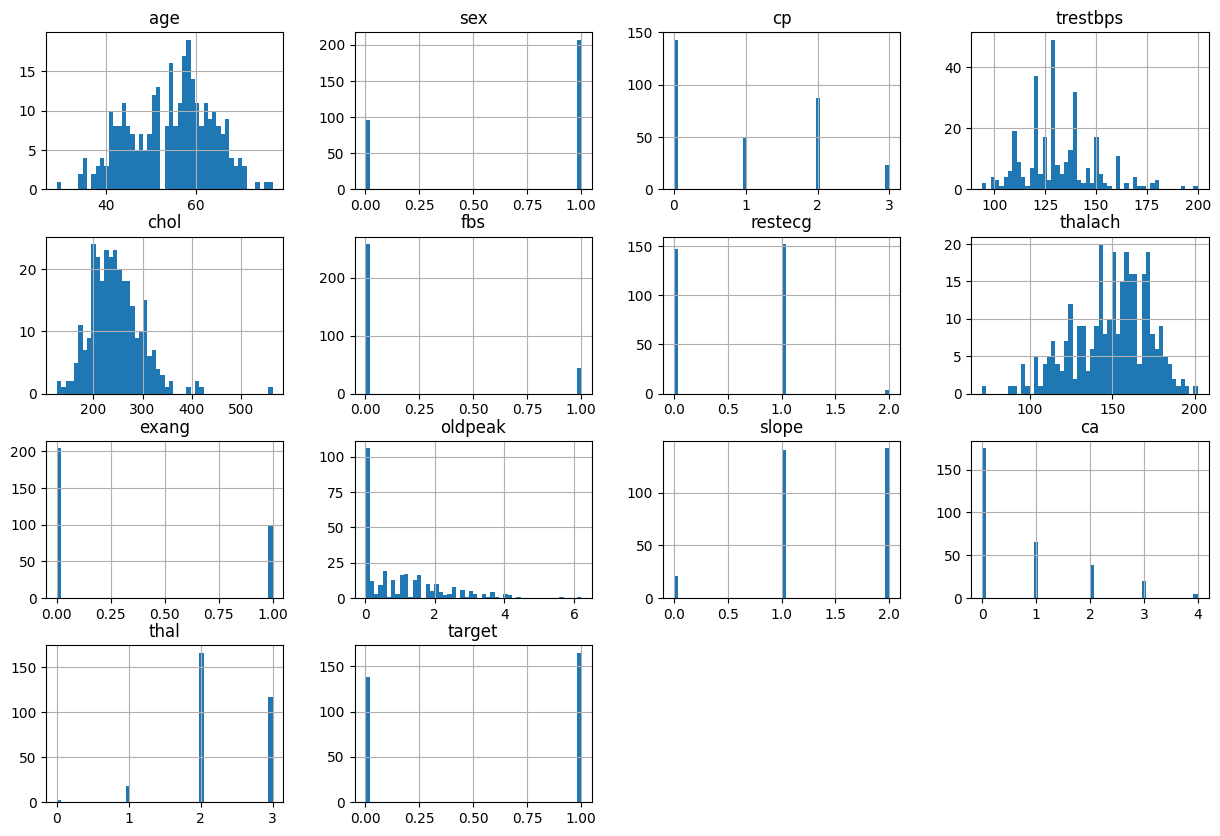

In [117]:
data.hist(bins=50, figsize=(15, 10))

Text(0, 0.5, 'Number of Instances')

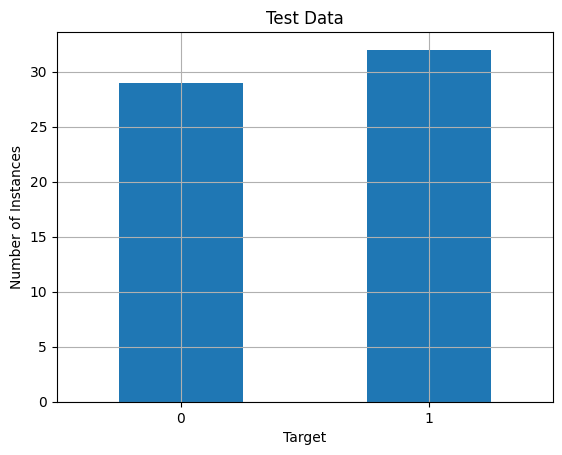

In [118]:
label_test.value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Test Data")
plt.xlabel("Target")
plt.ylabel("Number of Instances")

Text(0, 0.5, 'Number of Instances')

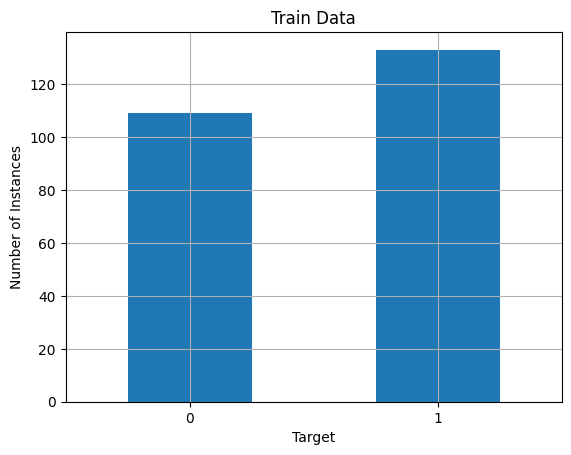

In [119]:
label_train.value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Train Data")
plt.xlabel("Target")
plt.ylabel("Number of Instances")

In [120]:
df = pd.concat([feature_train, label_train], axis=1)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2,1
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3,0
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2,1
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0


<Axes: xlabel='trestbps', ylabel='chol'>

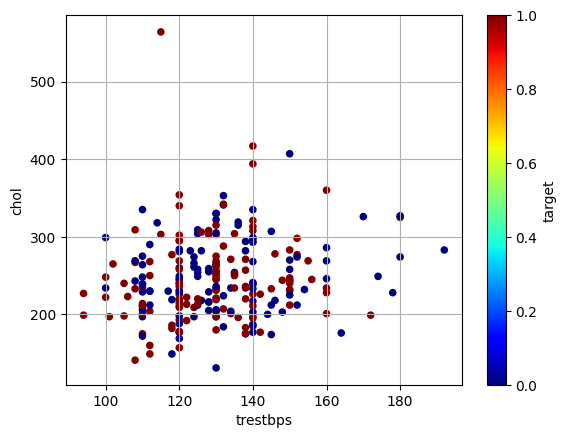

In [121]:
df.plot(kind="scatter", x="trestbps", y="chol", grid=True, cmap="jet", c="target")

array([[<Axes: xlabel='trestbps', ylabel='trestbps'>,
        <Axes: xlabel='chol', ylabel='trestbps'>,
        <Axes: xlabel='thalach', ylabel='trestbps'>,
        <Axes: xlabel='target', ylabel='trestbps'>],
       [<Axes: xlabel='trestbps', ylabel='chol'>,
        <Axes: xlabel='chol', ylabel='chol'>,
        <Axes: xlabel='thalach', ylabel='chol'>,
        <Axes: xlabel='target', ylabel='chol'>],
       [<Axes: xlabel='trestbps', ylabel='thalach'>,
        <Axes: xlabel='chol', ylabel='thalach'>,
        <Axes: xlabel='thalach', ylabel='thalach'>,
        <Axes: xlabel='target', ylabel='thalach'>],
       [<Axes: xlabel='trestbps', ylabel='target'>,
        <Axes: xlabel='chol', ylabel='target'>,
        <Axes: xlabel='thalach', ylabel='target'>,
        <Axes: xlabel='target', ylabel='target'>]], dtype=object)

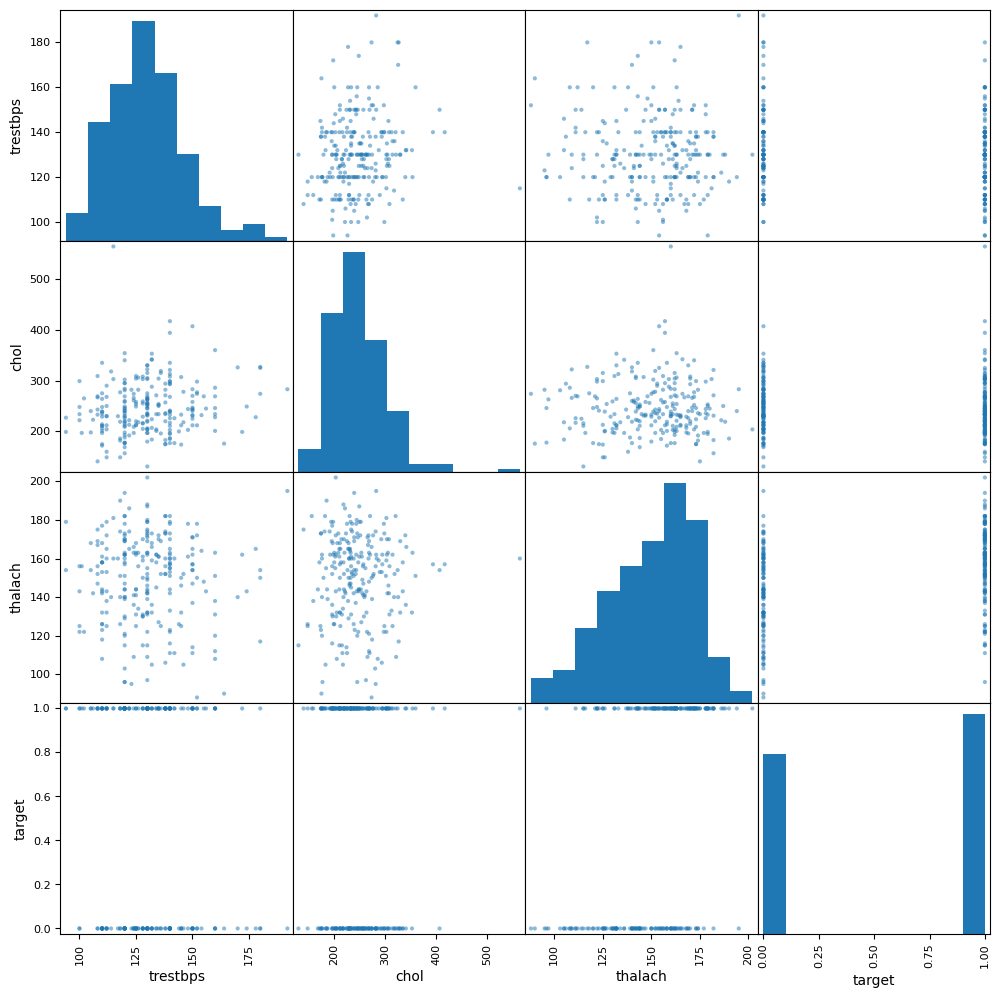

In [122]:
from pandas.plotting import scatter_matrix
attributes = ["trestbps", "chol", "thalach", "target"]
scatter_matrix(df[attributes], figsize=(12, 12))

# Correlation checking

In [123]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.099115,-0.103195,0.285224,0.231922,0.131451,-0.127500,-0.396378,0.148128,0.202352,-0.163345,0.297449,0.063933,-0.233782
sex,-0.099115,1.000000,-0.048505,-0.093901,-0.206036,0.042515,-0.050016,-0.032935,0.151280,0.149506,-0.043297,0.154897,0.220892,-0.304156
cp,-0.103195,-0.048505,1.000000,0.028868,-0.072812,0.160627,0.008473,0.290694,-0.360966,-0.143071,0.112465,-0.154172,-0.187221,0.407768
trestbps,0.285224,-0.093901,0.028868,1.000000,0.147664,0.186164,-0.067485,-0.037638,0.058674,0.132442,-0.039626,0.056918,0.006542,-0.104257
chol,0.231922,-0.206036,-0.072812,0.147664,1.000000,0.050426,-0.130684,0.012983,0.041559,0.111442,0.016556,0.022287,0.075106,-0.057714
fbs,0.131451,0.042515,0.160627,0.186164,0.050426,1.000000,-0.073940,-0.002542,0.007045,-0.004606,-0.062511,0.098354,-0.028194,-0.000924
restecg,-0.127500,-0.050016,0.008473,-0.067485,-0.130684,-0.073940,1.000000,0.016973,-0.018210,0.009423,0.032447,-0.042357,0.047144,0.084031
thalach,-0.396378,-0.032935,0.290694,-0.037638,0.012983,-0.002542,0.016973,1.000000,-0.397850,-0.344940,0.329956,-0.224513,-0.083921,0.393415
exang,0.148128,0.151280,-0.360966,0.058674,0.041559,0.007045,-0.018210,-0.397850,1.000000,0.314720,-0.264729,0.082691,0.241504,-0.443217
oldpeak,0.202352,0.149506,-0.143071,0.132442,0.111442,-0.004606,0.009423,-0.344940,0.314720,1.000000,-0.555152,0.225349,0.204291,-0.447305


# Features Scaling

In [125]:
from sklearn.preprocessing import MinMaxScaler

continuous_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

scaler = MinMaxScaler(feature_range=(-1, 1))

scaler.fit(feature_train[continuous_cols])

feature_train[continuous_cols] = scaler.transform(feature_train[continuous_cols])
feature_test[continuous_cols] = scaler.transform(feature_test[continuous_cols])

In [126]:
print(feature_train)
np.shape(feature_train)

          age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
132 -0.458333    1   1 -0.469388 -0.242494    0        1  0.298246      0   
202  0.208333    1   0  0.142857 -0.357968    0        0 -0.596491      1   
196 -0.291667    1   2  0.142857 -0.538106    0        1  0.035088      0   
75   0.083333    0   1 -0.163265 -0.450346    0        0  0.280702      0   
176  0.291667    1   0 -0.530612 -0.542725    1        1  0.263158      1   
..        ...  ...  ..       ...       ...  ...      ...       ...    ...   
188 -0.125000    1   2 -0.061224 -0.528868    0        1  0.315789      0   
71  -0.083333    1   2 -1.000000 -0.556582    0        1  0.157895      1   
106  0.666667    1   3  0.346939 -0.524249    1        0 -0.245614      0   
270 -0.291667    1   0 -0.469388 -0.454965    0        0 -0.017544      0   
102  0.416667    0   1 -0.061224 -0.704388    0        1  0.596491      0   

      oldpeak  slope  ca  thal  
132 -1.000000      2   0     2  
202 -0.71

(242, 13)

In [127]:
print(feature_test)
np.shape(feature_test)

          age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
179  0.166667    1   0  0.142857 -0.330254    0        0 -0.578947      1   
228  0.250000    1   3  0.551020 -0.274827    0        0  0.245614      0   
111  0.166667    1   2  0.142857 -1.023095    1        1  0.491228      0   
246  0.125000    0   0 -0.183673  0.284065    0        0  0.087719      1   
60   0.750000    0   2 -0.673469 -0.381062    1        0 -0.263158      0   
..        ...  ...  ..       ...       ...  ...      ...       ...    ...   
249  0.666667    1   2 -0.061224 -0.431871    0        0  0.017544      0   
104 -0.125000    1   2 -0.285714 -0.699769    0        1  0.315789      0   
300  0.625000    1   0  0.020408 -0.713626    1        1 -0.070175      0   
193  0.291667    1   0  0.040816 -0.302540    0        0 -0.052632      1   
184 -0.125000    1   0  0.142857 -0.482679    0        0 -0.298246      0   

      oldpeak  slope  ca  thal  
179 -0.785714      1   1     1  
228 -0.92

(61, 13)

# Training

# Logistic Regression

In [128]:
logis_model = LogisticRegression(max_iter=1000)
logis_model.fit(feature_train, label_train)

preds = logis_model.predict(feature_test)

accuracy = accuracy_score(label_test, preds)
print("Logistic Results:")
print(f"Accuracy: {accuracy}")

print("Confusion Matrix:")
print(confusion_matrix(label_test, preds))

print("Classification Report:")
print(classification_report(label_test, preds))

Logistic Results:
Accuracy: 0.8524590163934426
Confusion Matrix:
[[25  4]
 [ 5 27]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



# Random Forest Classifier

In [130]:
rand_model = RandomForestClassifier(n_estimators=100, random_state=42)
rand_model.fit(feature_train, label_train)

preds = rand_model.predict(feature_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(label_test, preds))
print(confusion_matrix(label_test, preds))
print(classification_report(label_test, preds))

Random Forest Results:
Accuracy: 0.8360655737704918
[[24  5]
 [ 5 27]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



# Decision Tree Classifier

In [131]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)

dt_model.fit(feature_train, label_train)

dt_preds = dt_model.predict(feature_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(label_test, dt_preds))
print("Confusion Matrix:\n", confusion_matrix(label_test, dt_preds))
print("Classification Report:\n", classification_report(label_test, dt_preds))

Decision Tree Results:
Accuracy: 0.8524590163934426
Confusion Matrix:
 [[26  3]
 [ 6 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



# KNeighborClassifier

In [132]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(feature_train, label_train)
knn_preds = knn_model.predict(feature_test)

print("KNN Results:")
print("Accuracy:", accuracy_score(label_test, knn_preds))
print("Confusion Matrix:\n", confusion_matrix(label_test, knn_preds))
print("Classification Report:\n", classification_report(label_test, knn_preds))

KNN Results:
Accuracy: 0.8524590163934426
Confusion Matrix:
 [[25  4]
 [ 5 27]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [140]:
feature_train, feature_test,  label_train, label_test = train_test_split(features, labels, test_size = 0.2, random_state=42)
feature_test

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,69,1,2,140,254,0,0,146,0,2.0,1,3,3
104,50,1,2,129,196,0,1,163,0,0.0,2,0,2
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
193,60,1,0,145,282,0,0,142,1,2.8,1,2,3


In [141]:
label_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64